In [14]:
#  Inputs
line_label = 'NeVIII' #'NeVIII', 'SiII', 'CIV', or 'cold_line'

# Threshold value: label (type) and range of percentageRange percentage of the threshold value
threshold_value_type = 'mean' #'max', 'min', 'mean', 'median'
range_percentage = [0., 40.]

# Wavelength ranges to crop spectra
wavelength_range_to_average = [1531.1147, 1551.7688]
wavelength_range_to_analyze_NeVIII = [1540.2, 1541.4]

# save average profile as .npy?
save_average_profile_map = 'yes' 


In [2]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import datetime as dt
from astropy.io import fits
import matplotlib.patches as patches
from scipy.odr import Model, RealData, ODR
from scipy.interpolate import interp1d
import matplotlib.lines as mlines
import sunpy.map
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames
import astropy.units as u


import sys
import os
sys.path.append(os.path.abspath('..'))
from auxiliar_functions.data_path import path_data_soho 
from auxiliar_functions.SOHO_aux_functions import *
from auxiliar_functions.calibration_parameters__output import *
from auxiliar_functions.spectroheliogram_functions import *
from auxiliar_functions.solar_rotation_variables import *
from auxiliar_functions.aux_functions import *
from auxiliar_functions.general_variables import *
from auxiliar_functions.NeVIII_rest_wavelength import *


/tmp/ipykernel_305054/1002911172.py:8: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import Model, RealData, ODR
/home/mario/anaconda3/envs/phd/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the intensity map and uncertainties
intensitymap_loaded_dic = np.load('intensity_map_'+line_label+'_interpolated.npz')
intensity_map = intensitymap_loaded_dic['intensity_map'] #2D-array
intensity_map_unc = intensitymap_loaded_dic['intensity_map_unc'] #2D-array
line_center_label = intensitymap_loaded_dic['line_center_label'] 
vmin_sumer, vmax_sumer = intensitymap_loaded_dic['vmin_vmax'] 

# Crop array in latitude 
intensity_map_croplat = intensity_map[slit_top_px:slit_bottom_px+1,:]
intensity_map_unc_croplat = intensity_map_unc[slit_top_px:slit_bottom_px+1,:]


In [4]:
## Rest wavelength used
rest_wavelength_label = 'Peter_and_Judge_1999' #'SUMER_atlas', 'Peter_1998', 'Dammasch_1999', 'Peter_and_Judge_1999', 'Kelly_database'
lam_0 = 2.*NeVIII_theoretical_wavelength_dic[rest_wavelength_label][0] #Angstrom
lam_unc_0 = 2.*NeVIII_theoretical_wavelength_dic[rest_wavelength_label][1] #Angstrom
print('Rest wavelength Ne VIII (2nd order):', lam_0, r'$\pm$', lam_unc_0, '\u212B')

Rest wavelength Ne VIII (2nd order): 1540.856 $\pm$ 0.014 Å


In [5]:
# Import SUMER data interpolated (wavelength calibrated)
data_interpolated_loaded = np.load('../auxiliar_functions/wcal4__spectral_image_list_intepolated_and_wavelength.npz', allow_pickle=True)
spectral_image_interpolated_list = data_interpolated_loaded['spectral_image_interpolated_list']
spectral_image_unc_interpolated_list = data_interpolated_loaded['spectral_image_unc_interpolated_list']
lam_sumer = data_interpolated_loaded['reference_wavelength']          # scalar (0‑d array; use a_loaded.item() for Python float)
lam_sumer_unc = data_interpolated_loaded['unc_reference_wavelength'] #uncertainty of lam_sumer
row_reference = int(data_interpolated_loaded['row_reference'])        # becomes a NumPy array or object array, so I conver it to integer again


In [6]:
lower_bound, upper_bound = get_bounds(intensitymap_croplat=intensity_map_croplat, range_percentage=range_percentage, threshold_value_type='mean')
print('lower_bound, upper_bound =', lower_bound, ',', upper_bound)

lower_bound, upper_bound = 0.0 , 0.17456889786348015


In [7]:
rowscols_inside_range = range_intensity_addresses_of_SUMER_spectroheliogram(intensitymap_croplat=intensity_map_croplat, lower_bound=lower_bound, upper_bound=upper_bound, slit_top_px=slit_top_px)
print('Number of pixels detected:', len(rowscols_inside_range))


Number of pixels detected: 6845


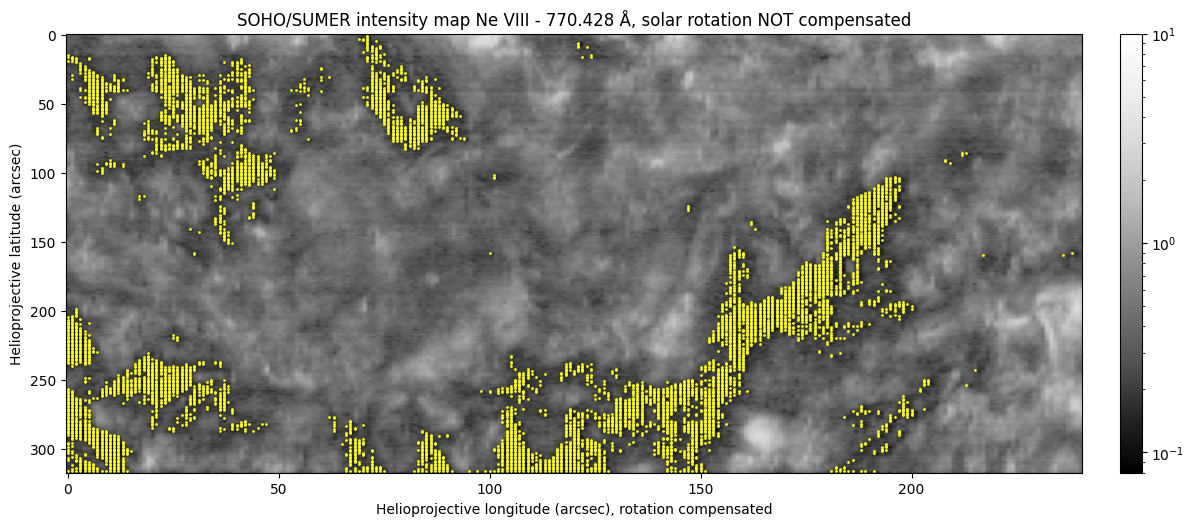

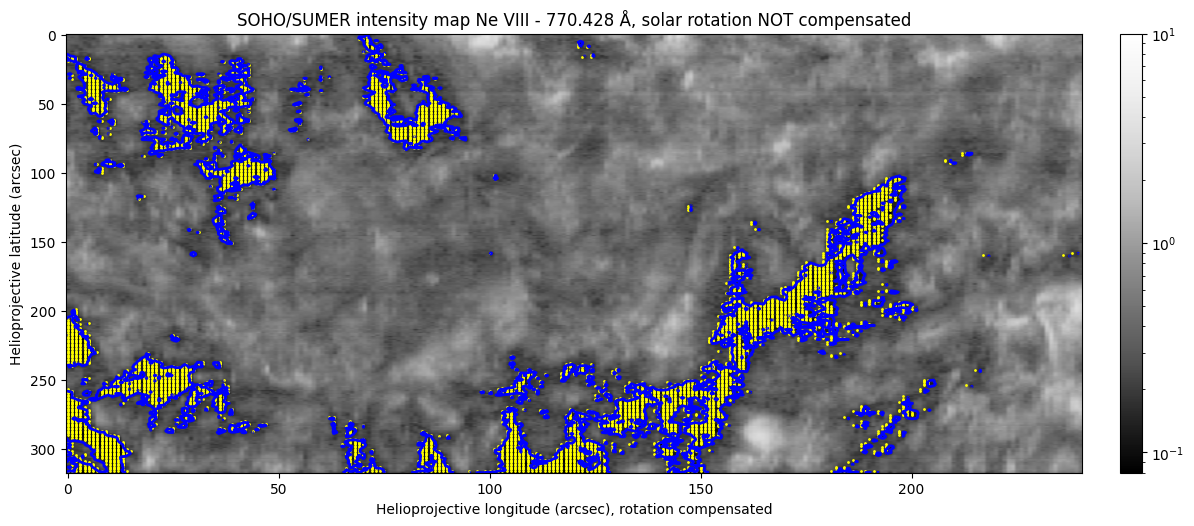

In [8]:
y_row_list_plot, x_col_list_plot = convert_list_of_pairs_to_2_lists(list_of_pairs=rowscols_inside_range)
y_row_list_plot = -slit_top_px + y_row_list_plot

arr2 = intensity_map_croplat
extent_ = [-0.5, arr2.shape[1]+0.5, arr2.shape[0]+0.5, -0.5]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 5.7))
img = ax.imshow(arr2, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), extent=extent_)
cbar = fig.colorbar(img, ax=ax, pad=0.03)
ax.set_title(f'SOHO/SUMER intensity map {line_center_label}, solar rotation NOT compensated')
ax.set_xlabel('Helioprojective longitude (arcsec), rotation compensated')
ax.set_ylabel('Helioprojective latitude (arcsec)')
ax.axis('auto') # Ensures equal scaling of axis x and y
ax.scatter(x=x_col_list_plot, y=y_row_list_plot, s=1, color='yellow')
plt.show(block=False)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 5.7))
img = ax.imshow(arr2, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), extent=extent_)
cbar = fig.colorbar(img, ax=ax, pad=0.03)
ax.set_title(f'SOHO/SUMER intensity map {line_center_label}, solar rotation NOT compensated')
ax.set_xlabel('Helioprojective longitude (arcsec), rotation compensated')
ax.set_ylabel('Helioprojective latitude (arcsec)')
ax.axis('auto') # Ensures equal scaling of axis x and y
ax.scatter(x=x_col_list_plot, y=y_row_list_plot, s=1, color='yellow')
contour_lower = ax.contour(arr2[::-1], levels=[lower_bound], colors='red', linewidths=2, extent=extent_)
contour_upper = ax.contour(arr2[::-1], levels=[upper_bound], colors='blue', linewidths=2, extent=extent_)
legend_elements = [
    mlines.Line2D([],[],color='red', label=f'{lower_bound}'),
    mlines.Line2D([],[],color='blue', label=f'{upper_bound}')]
plt.show(block=False)

In [9]:
# Average spectra of the pixels selected
lam_sumer_av, rad_sumer_av, erad_sumer_av = average_profiles_from_pixels_selected_from_interpolated_data(wavelength_range_=wavelength_range_to_average, data_interpolated_loaded_=data_interpolated_loaded, rows_cols_of_spectroheliogram=rowscols_inside_range)

# crop near Ne VIII
lam_sumer_avNeVIII, idx_sumer_crop_ = crop_range(list_to_crop=lam_sumer_av, range_values=wavelength_range_to_analyze_NeVIII)
rad_sumer_avNeVIII = rad_sumer_av[idx_sumer_crop_[0]:idx_sumer_crop_[1]+1]
erad_sumer_avNeVIII = erad_sumer_av[idx_sumer_crop_[0]:idx_sumer_crop_[1]+1]


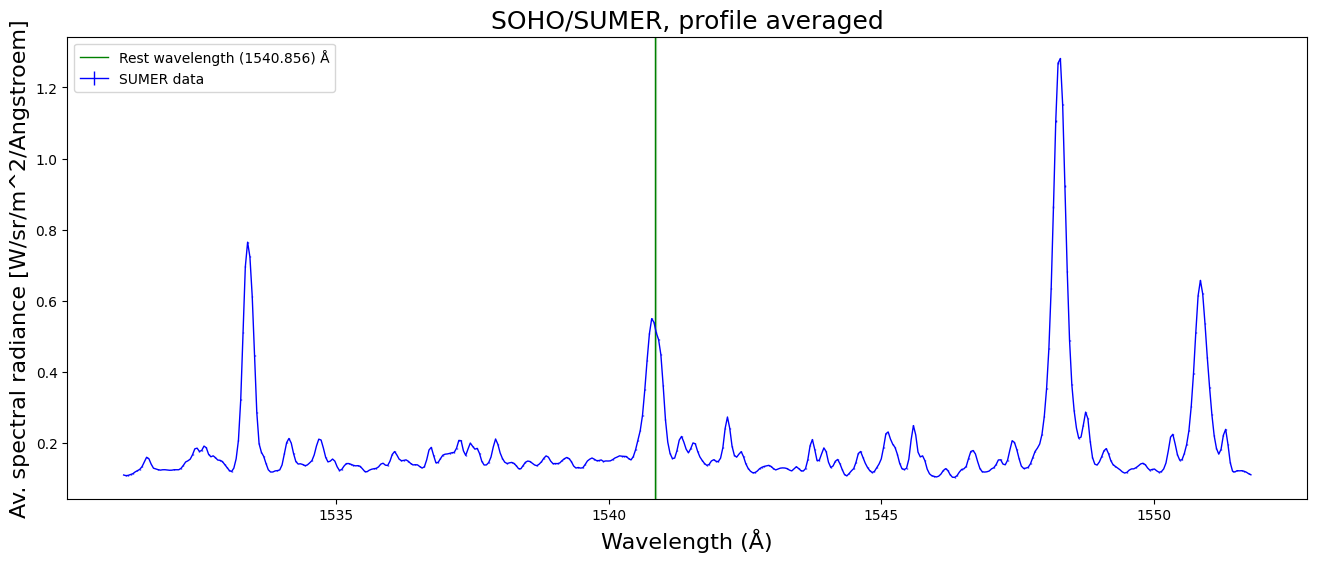

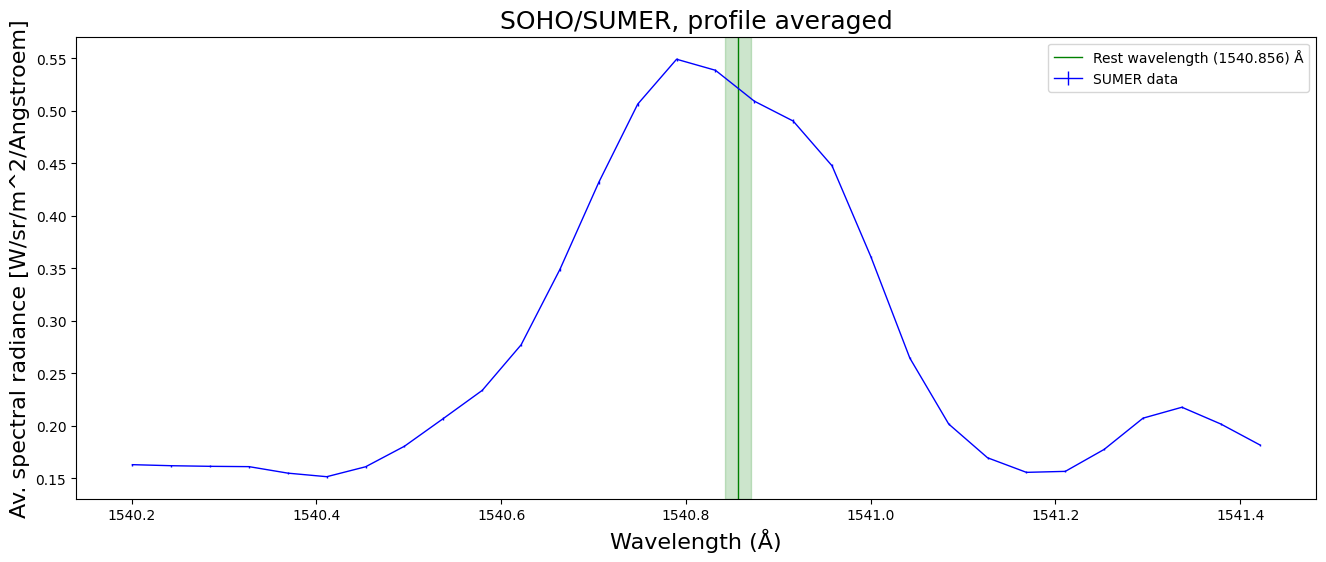

In [10]:
# Show averaged spectra
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
ax.errorbar(x=lam_sumer_av, y=rad_sumer_av, yerr=erad_sumer_av, color='blue', linewidth=1., label='SUMER data')
ax.set_title(f'SOHO/SUMER, profile averaged', fontsize=18) 
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel(f'Av. spectral radiance [W/sr/m^2/Angstroem]', color='black', fontsize=16)
ax.axvline(lam_0, color='green', linewidth=1., label=f'Rest wavelength ({lam_0})'' \u212B')
ax.axvspan(lam_0-lam_unc_0, lam_0+lam_unc_0, color='green', alpha=0.2)
ax.legend()
plt.show(block=False)


# Show averaged spectra cropped around Ne VIII
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
ax.errorbar(x=lam_sumer_avNeVIII, y=rad_sumer_avNeVIII, yerr=erad_sumer_avNeVIII, color='blue', linewidth=1., label='SUMER data')
ax.set_title(f'SOHO/SUMER, profile averaged', fontsize=18) 
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel(f'Av. spectral radiance [W/sr/m^2/Angstroem]', color='black', fontsize=16)
ax.axvline(lam_0, color='green', linewidth=1., label=f'Rest wavelength ({lam_0})'' \u212B')
ax.axvspan(lam_0-lam_unc_0, lam_0+lam_unc_0, color='green', alpha=0.2)
ax.legend()
plt.show(block=False)

In [13]:
# save average profile as .npy
if save_average_profile_map == 'yes':
    range_numbers_to_string = '__'.join(f"{x:.2f}".replace('.', '_').rstrip('0') if f"{x:.2f}"[-1] != '0' else f"{x:.1f}".replace('.', '_') for x in range_percentage) 
    filename_profile = 'average_profile__' + range_numbers_to_string + '__' + threshold_value_type + '_of_intensitymap_' + line_label + '___'
    foldepath_profile = '../auxiliar_functions/'
    np.savez(foldepath_profile+filename_profile, lam_sumer_av=lam_sumer_av, rad_sumer_av=rad_sumer_av, erad_sumer_av=erad_sumer_av, lam_sumer_avNeVIII=lam_sumer_avNeVIII, rad_sumer_avNeVIII=rad_sumer_avNeVIII, erad_sumer_avNeVIII=erad_sumer_avNeVIII)


"""
In order to load the intensity map in another file (or this one), do the next:

profiles_loaded_dic = np.load(filename_profile)
lam_sumer_av = profiles_loaded_dic['lam_sumer_av'] #Angstrom
rad_sumer_av = profiles_loaded_dic['rad_sumer_av'] #[W/sr/m^2/Angstroem]
erad_sumer_av = profiles_loaded_dic['erad_sumer_av'] #[W/sr/m^2/Angstroem]
lam_sumer_avNeVIII = profiles_loaded_dic['lam_sumer_avNeVIII'] #Angstrom
rad_sumer_avNeVIII = profiles_loaded_dic['rad_sumer_avNeVIII'] #[W/sr/m^2/Angstroem]
erad_sumer_avNeVIII = profiles_loaded_dic['erad_sumer_avNeVIII'] #[W/sr/m^2/Angstroem]
"""
""

''